In [34]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from imblearn import under_sampling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from Corte_II.regresion_logistica import x_train, x_test, y_train, y_test

In [19]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [20]:
df["Class"].unique()

<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

In [21]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [23]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [24]:
hay_duplicados = df.duplicated().any()
print(hay_duplicados)

True


In [25]:
df.drop_duplicates(inplace=True)
hay_duplicados = df.duplicated().any()
print(hay_duplicados)

False


<Axes: xlabel='Class', ylabel='count'>

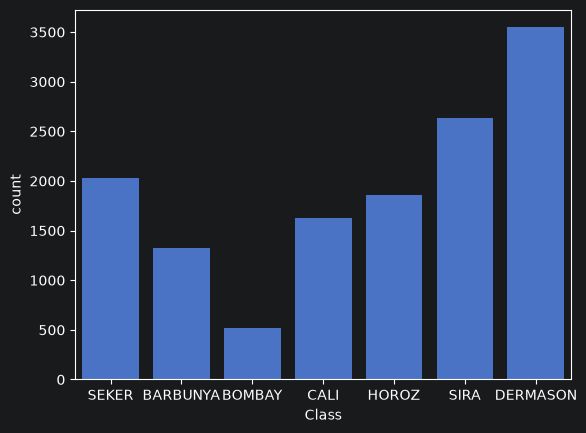

In [26]:
# validar si el dataset esta balanceado
import seaborn as sns

sns.countplot(x = "Class", data = df)

In [27]:
from imblearn.under_sampling import RandomUnderSampler

under_sampling = RandomUnderSampler(random_state=42)

x = df.drop("Class", axis = 1)
y = df.Class

In [28]:
x_under, y_under = under_sampling.fit_resample(x,y)

<Axes: xlabel='Class', ylabel='count'>

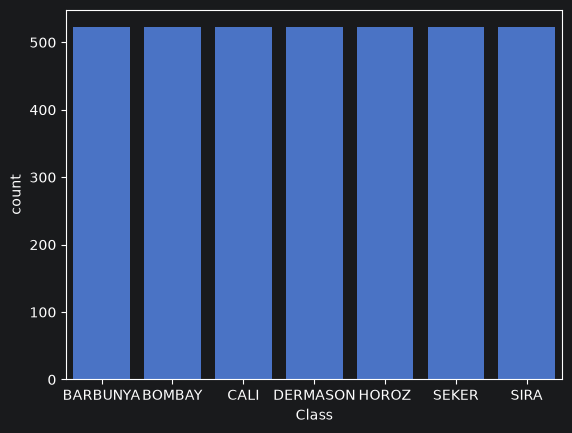

In [29]:
sns.countplot(x = y_under)

In [30]:
y_under.replace(["SEKER","BARBUNYA","BOMBAY","CALI","HOROZ","SIRA","DERMASON"],[1,2,3,4,5,6,7], inplace=True)
y_under.unique()

array([2, 3, 4, 7, 5, 1, 6], dtype=object)

In [31]:
df_new = x_under
df_new["Class"] = y_under

<Axes: >

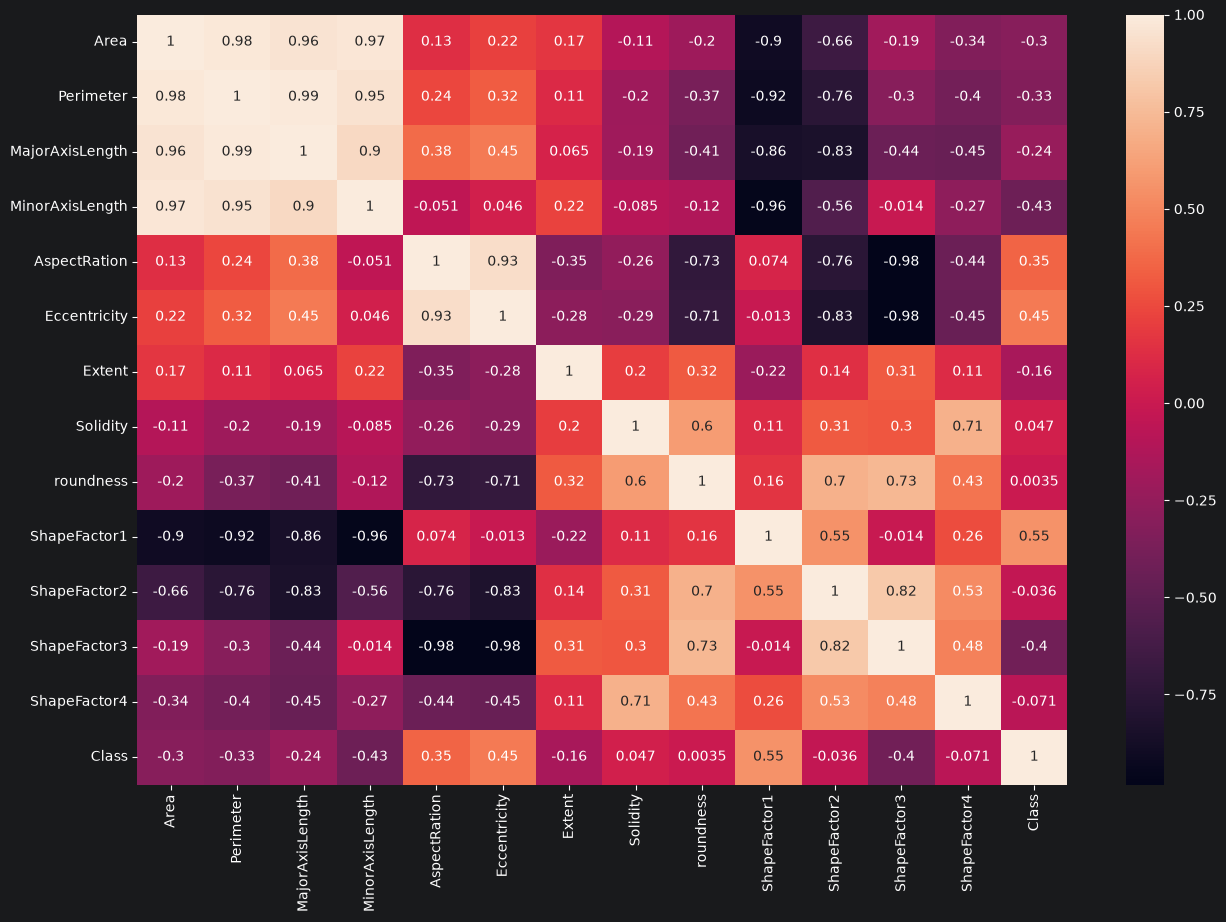

In [38]:
from matplotlib import pyplot as plt

plt.figure(figsize=(15,10))
sns.heatmap(df_new.corr(), annot = True)


In [37]:
x_under.drop(["ConvexArea", "Compactness", "EquivDiameter"], axis = 1, inplace = True )

KeyError: "['ConvexArea', 'Compactness', 'EquivDiameter'] not found in axis"

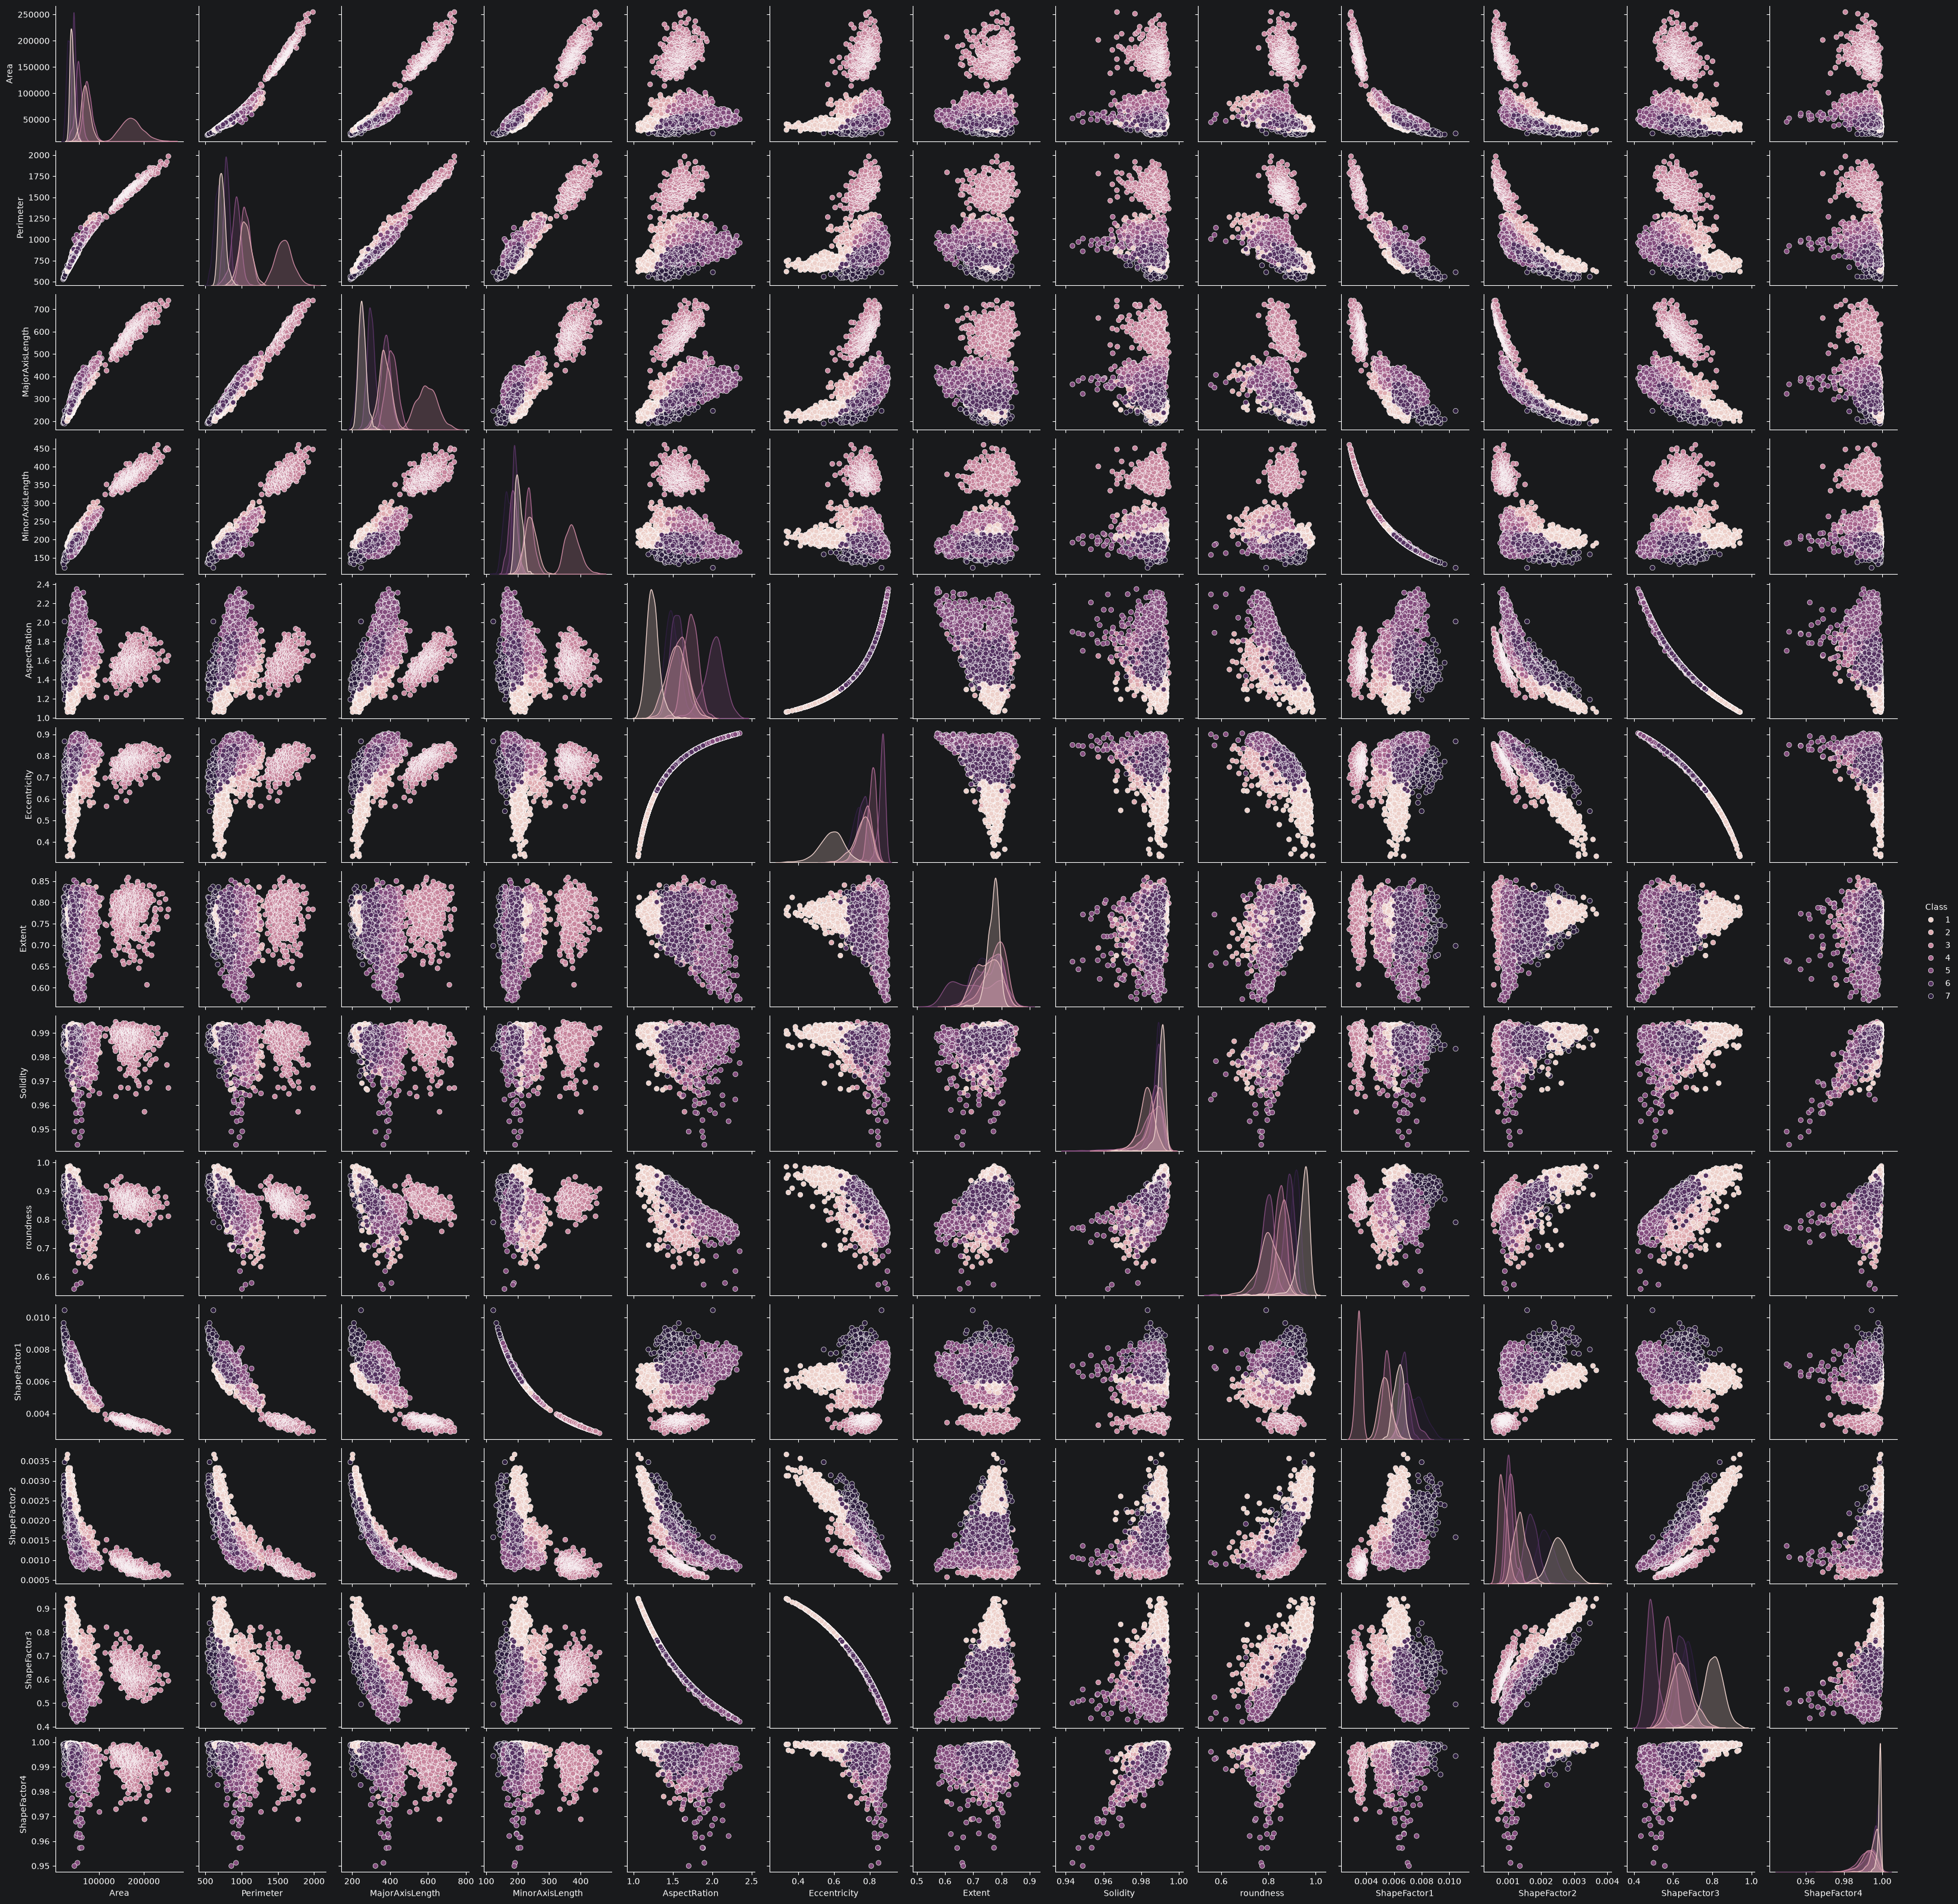

In [39]:
sns.pairplot(df_new, hue = "Class")

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x_under, y_under, test_size = 0.3, random_state = 42)

In [41]:
from sklearn.preprocessing import StandardScaler

scalet = StandardScaler()
X_train = scalet.fit_transform(x_train)
X_test = scalet.fit_transform(x_test)

In [42]:
x_test

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,Extent,Solidity,roundness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
4577,73365,1026.958,395.964392,238.402701,1.660906,0.798435,0.761103,0.982247,0.874165,0.005397,0.001182,0.595781,0.989536,4
13404,39728,736.791,270.417463,187.662265,1.440979,0.720002,0.810048,0.989736,0.919640,0.006807,0.002009,0.691731,0.996770,7
2195,58361,919.022,328.538574,227.154030,1.446325,0.722465,0.717159,0.983336,0.868322,0.005629,0.001646,0.688431,0.995694,2
8076,41567,768.363,286.848953,185.110200,1.549612,0.763910,0.796852,0.987739,0.884760,0.006901,0.001761,0.643209,0.996725,6
6902,58122,969.626,410.206064,182.044054,2.253334,0.896132,0.806824,0.991082,0.776858,0.007058,0.000842,0.439791,0.990996,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3789,198209,1672.222,617.134207,412.156758,1.497329,0.744291,0.786762,0.988145,0.890729,0.003114,0.000843,0.662635,0.992182,3
3772,192812,1678.819,654.847755,378.219282,1.731397,0.816342,0.814956,0.990100,0.859679,0.003396,0.000687,0.572484,0.991197,3
2451,65235,1017.685,329.699539,253.314520,1.301542,0.640067,0.752787,0.984441,0.791523,0.005054,0.001820,0.764107,0.994517,2
5702,44258,832.579,334.904744,169.468669,1.976204,0.862521,0.658562,0.985504,0.802326,0.007567,0.001178,0.502411,0.992867,5
